In [22]:
import sys
from utils import *
from tkinter import filedialog
import tkinter as tk

## Leer Arhivo `.pkl` con todos los modelos

In [24]:
# Crear ventana temporal para seleccionar archivo
root = tk.Tk()
root.withdraw()  # Ocultar ventana principal

PATH_MODEL = filedialog.askopenfilename(
    title="Seleccione el archivo del modelo",
    filetypes=[("Pickle files", "*.pkl"), ("All files", "*.*")]
)

if PATH_MODEL:
    with open(PATH_MODEL, 'rb') as pkl_file:
        all_results = pickle.load(pkl_file)
    print(f"Archivo cargado: {PATH_MODEL}")
else:
    print("No se seleccionó ningún archivo")

#obtener el path del directorio del modelo
model_dir = os.path.dirname(PATH_MODEL)
print(f"Directorio del modelo: {model_dir}")


Archivo cargado: D:/Estudio/OneDrive - Universidad de Antioquia/Estudio/PAI/Codigo/Code_Quindio/Resultados/classification_exclude_prod/class_results_individual_elements.pkl
Directorio del modelo: D:/Estudio/OneDrive - Universidad de Antioquia/Estudio/PAI/Codigo/Code_Quindio/Resultados/classification_exclude_prod


In [25]:
# obtener nombre de ultima carpeta del path del modelo
model_name = os.path.basename(model_dir)
print(f"Nombre del modelo: {model_name}")

Nombre del modelo: classification_exclude_prod


In [26]:
folder_model_name = os.path.basename(model_dir)
if "cuartiles" in folder_model_name:
    CFG.cuartiles_train = True
    CFG.individual_train = False
else:
    CFG.cuartiles_train = False
    CFG.individual_train = True

print(f"Entrenamiento por cuartiles: {CFG.cuartiles_train}")
print(f"Entrenamiento individual: {CFG.individual_train}")

Entrenamiento por cuartiles: False
Entrenamiento individual: True


## Matriz de Confusion

In [27]:
# iterar all_results
for key, value in all_results.items():
    for resultado in value:
        print(resultado['n_clases'])
        print(resultado['confusion_matrix_test'])


3_Nitrogen
[[174  26  28]
 [ 18 179  32]
 [ 13  26 192]]
3_Phosphorus
[[179  29  20]
 [ 35 171  25]
 [ 30  38 161]]
3_Potassium
[[182  24  23]
 [ 23 178  29]
 [ 21  30 178]]
3_Nitrogen
[[174  26  28]
 [ 32 159  38]
 [ 40  18 173]]
3_Phosphorus
[[183  24  21]
 [ 42 160  29]
 [ 34  31 164]]
3_Potassium
[[168  33  28]
 [ 28 152  50]
 [ 26  37 166]]
3_Nitrogen
[[175  26  27]
 [ 54 152  23]
 [ 36  25 170]]
3_Phosphorus
[[184  30  14]
 [ 59 155  17]
 [ 50  35 144]]
3_Potassium
[[175  32  22]
 [ 46 161  23]
 [ 47  44 138]]
3_Nitrogen
[[167  32  29]
 [ 33 152  44]
 [ 28  22 181]]
3_Phosphorus
[[170  27  31]
 [ 42 144  45]
 [ 43  39 147]]
3_Potassium
[[158  33  38]
 [ 23 150  57]
 [ 21  32 176]]
3_Nitrogen
[[175  27  26]
 [ 24 171  34]
 [ 14  16 201]]
3_Phosphorus
[[190  22  16]
 [ 30 177  24]
 [ 20  36 173]]
3_Potassium
[[190  18  21]
 [ 20 186  24]
 [ 22  30 177]]


In [28]:
if CFG.cuartiles_train:
    for key, value in all_results.items():
        for resultado in value:
            plot_confusion_matrix(resultado['confusion_matrix_test'], classes=['High','Low'], 
                                title=f"Confusion Matrix - {key} - {resultado['n_clases'].split('_')[1] } model")

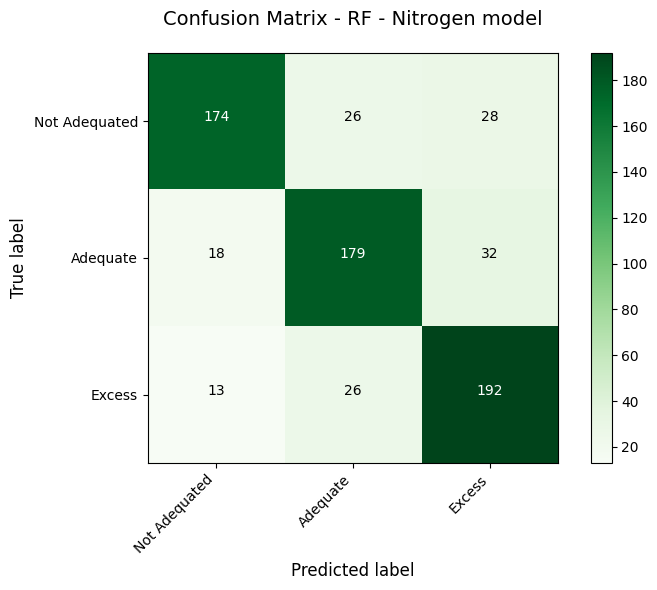

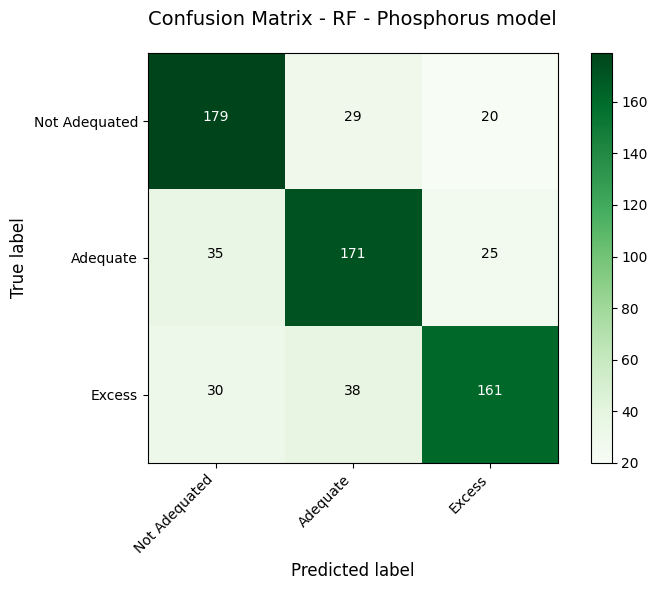

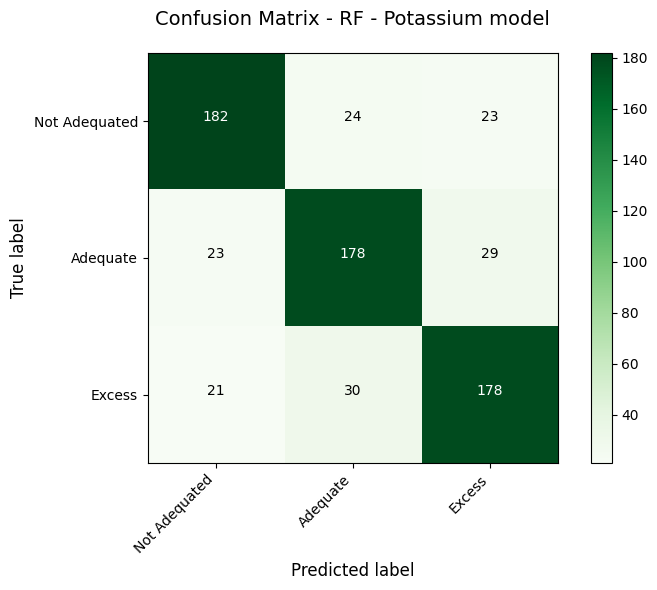

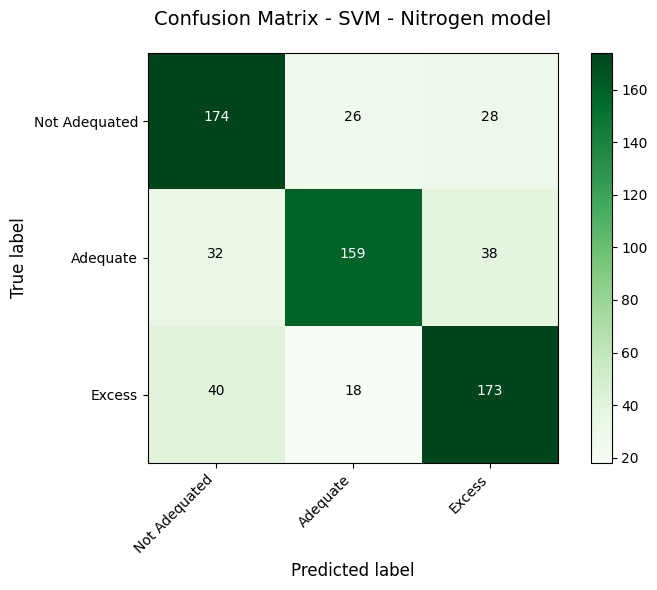

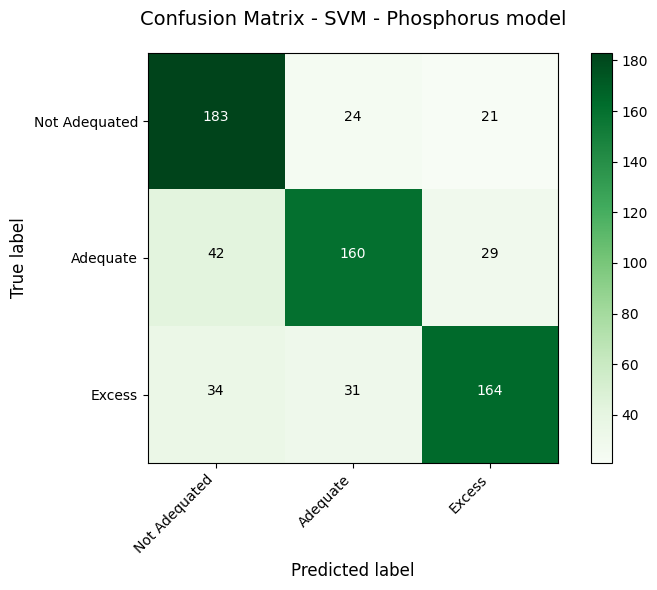

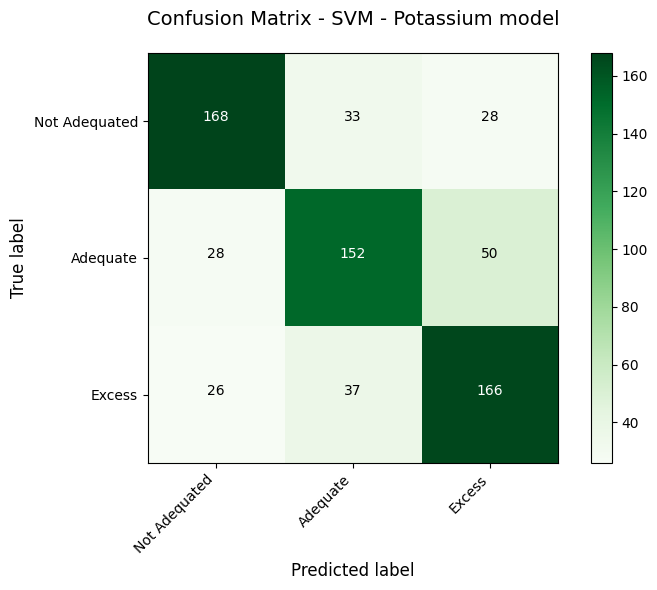

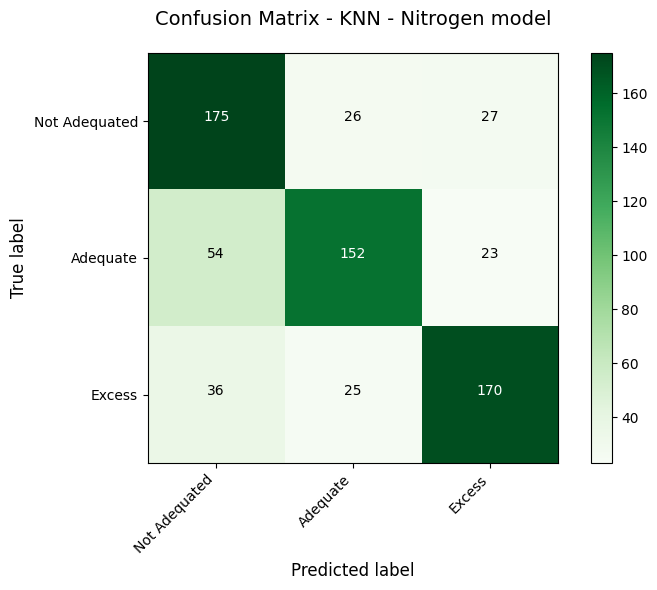

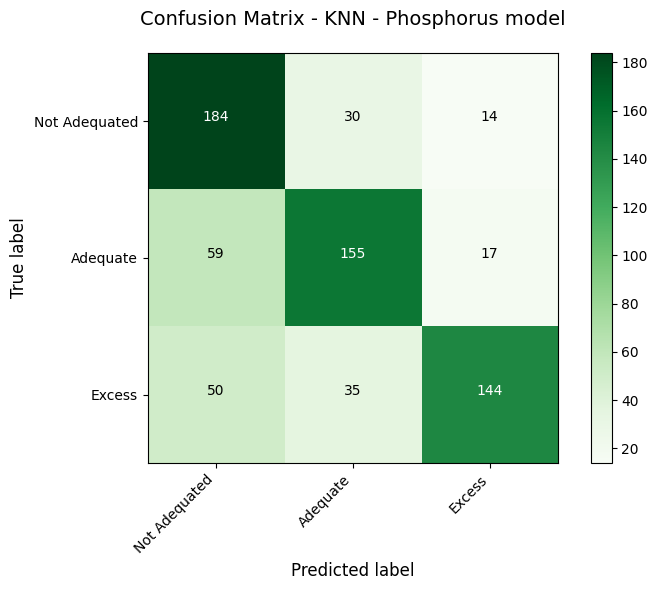

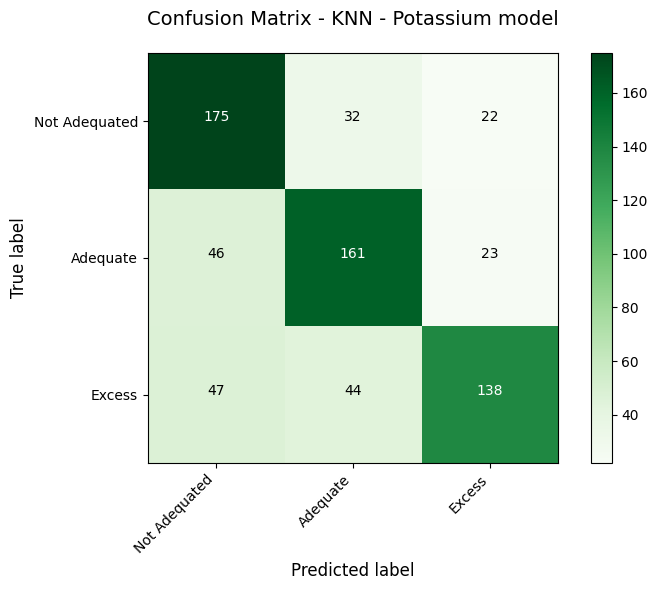

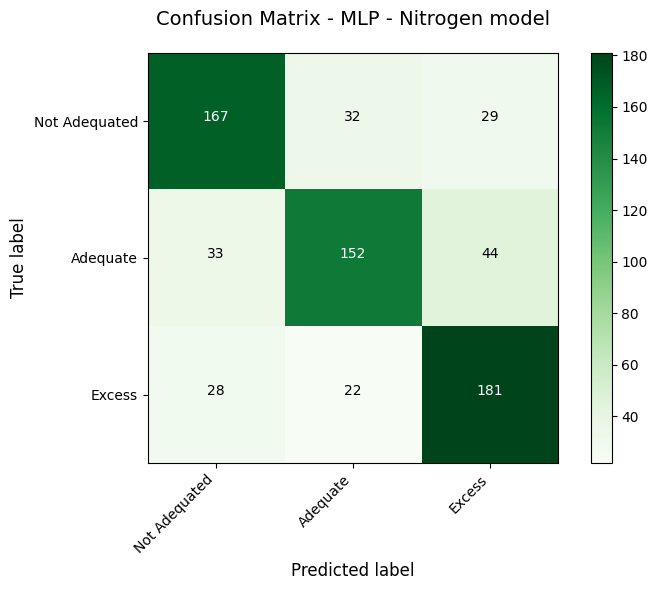

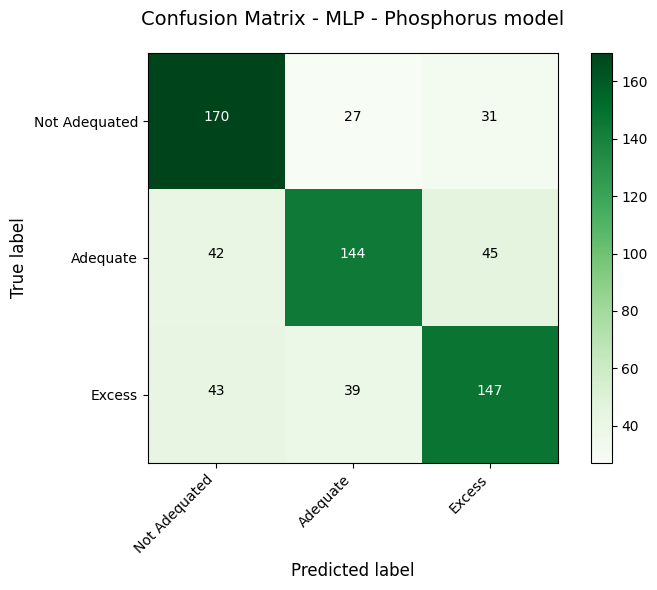

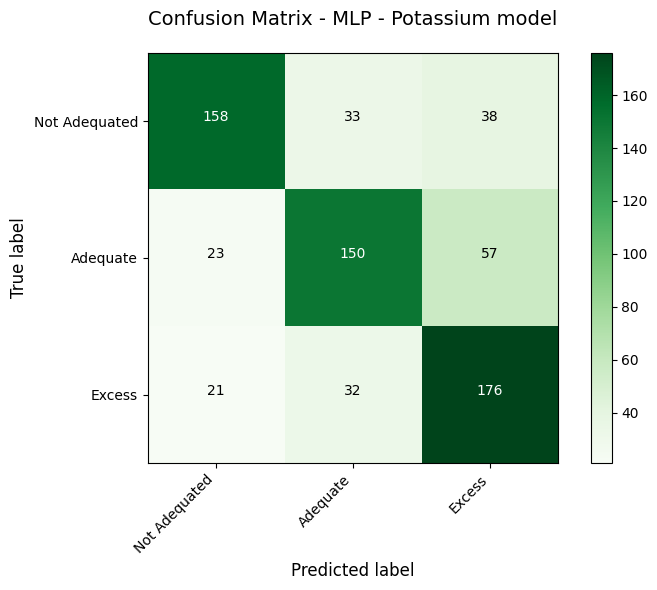

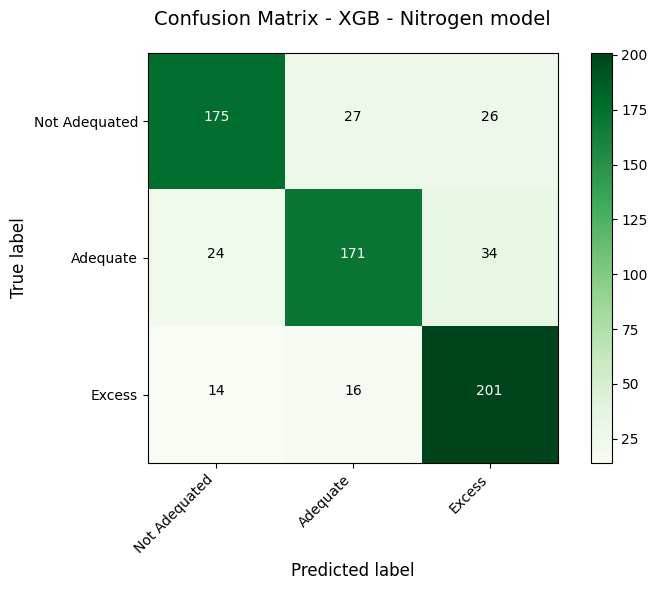

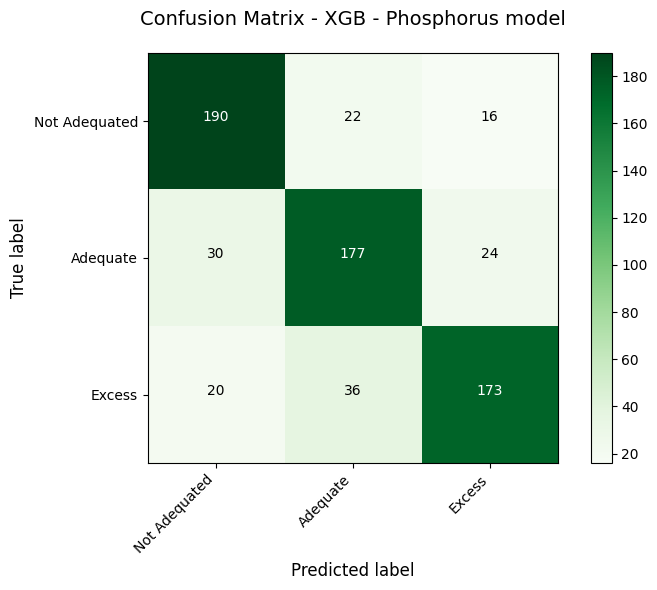

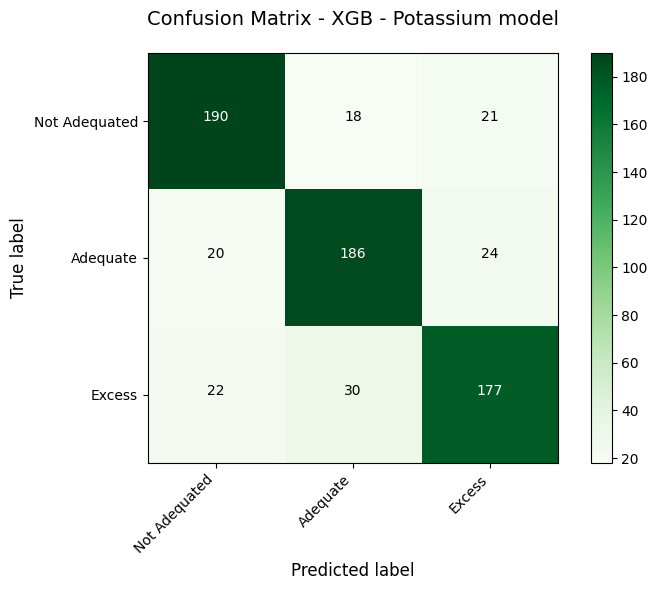

In [29]:
if CFG.individual_train:
    for key, value in all_results.items():
        for resultado in value:
            plot_confusion_matrix(resultado['confusion_matrix_test'], classes=['Not Adequated','Adequate','Excess'], 
                                title=f"Confusion Matrix - {key} - {resultado['n_clases'].split('_')[1] } model")

## Iterar Varias veces SHAP values

* entrenar modelo
* predecir con datos de test

* ¿iterar varias veces con diferentes porciones de test?
* ¿entrenar varias shufling data?
* almacenar datos en carpetas/rutas diferentes


In [30]:
def plot_shap_importance(model, X_test, feature_names, model_type='tree', n_clases=2, title="SHAP Feature Importance", path=None, iteration = 0):
    """Genera gráficos de importancia SHAP.

    Args:
        model: Modelo entrenado.
        X_test (DataFrame): Datos de prueba.
        feature_names (list): Nombres de las características.
        model_type (str): 'tree' para TreeExplainer, 'kernel' para KernelExplainer.
                         'kernel' se utiliza para modelos no basados en árboles como SVM, KNN, MLP.
        n_clases (int): Número de clases en el modelo.
        title (str): Título del gráfico.
        path (str): Ruta para guardar el gráfico (sin extensión).
    Returns:
        tuple: (shap_values, explainer, shap_fig, X_df_used)

    """
    X_df = pd.DataFrame(X_test, columns=feature_names)

    if model_type == 'tree':
        try:
            # Try with model_output parameter for better compatibility
            if hasattr(model, 'get_booster'):  # XGBoost specific
                explainer = shap.TreeExplainer(model, model_output='raw')
            else:
                explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_df)
        except (ValueError, AttributeError) as e:
            if "could not convert string to float" in str(e) or "base_score" in str(e):
                # Fallback: use predict_proba with KernelExplainer for XGBoost multiclass
                print(f"Warning: TreeExplainer failed for {type(model).__name__}. Using KernelExplainer as fallback.")
                background = shap.sample(X_df, min(100, len(X_df)), random_state=42 + iteration)
                explainer = shap.KernelExplainer(model.predict_proba, background)
                shap_values = explainer.shap_values(background, nsamples=100)
                X_df_used = background
                
                # Skip to plotting
                fig = plt.figure(figsize=(12, 6))
                shap.summary_plot(shap_values, X_df_used, feature_names=feature_names,
                                 plot_type="bar", show=False)
                plt.title(title, fontsize=14, pad=20)
                plt.xlabel("Mean |SHAP value|", fontsize=12)
                if path:
                    plt.savefig(f"{path}_bar_{iteration}.png", dpi=300, bbox_inches='tight')
                plt.tight_layout()
                return shap_values, explainer, fig, X_df_used
            else:
                raise
        
        X_df_used = X_df
    else:  # kernel
        # Usar muestra para KernelExplainer (más rápido)
        background = shap.sample(X_df, min(100, len(X_df)), random_state=42 + iteration)
        explainer = shap.KernelExplainer(model.predict_proba, background)
        shap_values = explainer.shap_values(background, nsamples=100)
        X_df_used = background

    # Gráfico de barras
    fig = plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_df_used, feature_names=feature_names,
                     plot_type="bar", show=False)
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel("Mean |SHAP value|", fontsize=12)
    if path:
        plt.savefig(f"{path}_bar_{iteration}.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()

    return shap_values, explainer, fig, X_df_used

def extract_common_values_from_csv(csv_path):
    """
    Lee un CSV y extrae los valores comunes en todas las columnas,
    ordenados por la suma de sus posiciones (ranking) en cada columna.
    
    Cada valor en una columna recibe un puntaje igual a su índice de fila
    (posición 0 = más importante). Para los valores comunes a todas las columnas,
    se suman sus posiciones y se ordenan de menor a mayor (mejor ranking global primero).
    
    Args:
        csv_path (str): Ruta al archivo CSV
        
    Returns:
        list: Lista de valores comunes ordenados por ranking agregado (menor suma = mejor)
    """
    df = pd.read_csv(csv_path)
    
    # Para cada columna, construir un dict {valor: posición}
    column_rankings = []
    column_sets = []
    for col in df.columns:
        rank_dict = {}
        for pos, val in enumerate(df[col]):
            if pd.notna(val) and str(val).strip() != '':
                rank_dict[val] = pos
        column_rankings.append(rank_dict)
        column_sets.append(set(rank_dict.keys()))
    
    if not column_sets:
        return []
    
    # Valores comunes en todas las columnas
    common_values = set.intersection(*column_sets)
    
    if not common_values:
        return []
    
    # Calcular la suma de posiciones para cada valor común
    scores = {}
    for val in common_values:
        scores[val] = sum(rank_dict[val] for rank_dict in column_rankings) # iterar en cada diccionario de cada columna
    
    # Ordenar por puntaje agregado (menor suma = mejor ranking global)
    sorted_values = sorted(scores.keys(), key=lambda v: scores[v])
    
    return sorted_values

def extract_frequent_values_from_csv(csv_path, threshold_percentage=80):
    """
    Lee un CSV y extrae los valores que aparecen en al menos el threshold_percentage
    de las columnas, ordenados por la suma de sus posiciones (ranking) en cada columna.
    
    A diferencia de extract_common_values_from_csv que requiere que los valores aparezcan
    en TODAS las columnas, esta función permite un umbral configurable.
    
    Cada valor en una columna recibe un puntaje igual a su índice de fila
    (posición 0 = más importante). Para los valores que aparecen en al menos el
    threshold_percentage de columnas, se suman sus posiciones y se ordenan de
    menor a mayor (mejor ranking global primero).
    
    Args:
        csv_path (str): Ruta al archivo CSV
        threshold_percentage (float): Porcentaje mínimo de columnas en las que debe 
                                     aparecer un valor (default: 80)
        
    Returns:
        list: Lista de valores frecuentes ordenados por ranking agregado (menor suma = mejor)
    """
    df = pd.read_csv(csv_path)
    
    # Para cada columna, construir un dict {valor: posición}
    column_rankings = []
    column_sets = []
    for col in df.columns:
        rank_dict = {}
        for pos, val in enumerate(df[col]):
            if pd.notna(val) and str(val).strip() != '':
                rank_dict[val] = pos
        column_rankings.append(rank_dict)
        column_sets.append(set(rank_dict.keys()))
    
    if not column_sets:
        return []
    
    # Calcular cuántas columnas mínimas debe aparecer un valor
    num_columns = len(column_sets)
    min_appearances = int(np.ceil(num_columns * threshold_percentage / 100))
    
    # Obtener todos los valores únicos
    all_values = set()
    for col_set in column_sets:
        all_values.update(col_set)
    
    # Filtrar valores que aparecen en al menos threshold_percentage de columnas
    frequent_values = set()
    for val in all_values:
        count = sum(1 for col_set in column_sets if val in col_set)
        if count >= min_appearances:
            frequent_values.add(val)
    
    if not frequent_values:
        return []
    
    # Calcular la suma de posiciones para cada valor frecuente
    # Solo sumamos las posiciones en las columnas donde el valor aparece
    scores = {}
    for val in frequent_values:
        scores[val] = sum(rank_dict[val] for rank_dict in column_rankings if val in rank_dict)
    
    # Ordenar por puntaje agregado (menor suma = mejor ranking global)
    sorted_values = sorted(scores.keys(), key=lambda v: scores[v])
    
    return sorted_values


In [31]:
# =========== LOAD DATA =================

df_imputed = pd.read_csv(CFG.path_df_imputed_corrected)
df_imputed.columns = clean_feature_names(df_imputed.columns)


# Preparar datos
X_train, X_test, y_train, y_test, feature_names, class_dist = preparar_datos(
    df_imputed, n_clases=3, element="Nitrogen", best_variables=None, CFG=CFG
)


In [32]:
(all_results['RF'][0].keys())

dict_keys(['y_true', 'y_pred', 'n_clases', 'model_name', 'accuracy_train', 'accuracy_test', 'f1_train', 'f1_train_macro', 'f1_test', 'f1_macro_test', 'best_params', 'class_distribution', 'classification_report', 'confusion_matrix_test', 'grid_search', 'shap_values', 'X_scaled_df'])

### Calcular SHAP Values `NUMBER_ITERATIONS` 

In [35]:
NUMBER_ITERATIONS = 10
results_iteration_shap = {}
for i in range(5, NUMBER_ITERATIONS +1):
    for algorithm, value in all_results.items():
        counter = 0
        for modelo in value:
            
            print(f"Iteración {i+1} - Algoritmo: {algorithm}")
            if 'grid_search' in modelo:
                pipeline = modelo['grid_search'].best_estimator_
            else:
                pipeline = modelo['best_model']
            output_dir = os.path.join(os.getcwd(), "shap_outputs", model_name, str(i))
            os.makedirs(output_dir, exist_ok=True)

            scaler = pipeline.named_steps['scaler']
            clf = pipeline.named_steps['clf']
            X_test_scaled = scaler.transform(X_test)

            shap_values, explainer, fig, X_df_used = plot_shap_importance(
                clf, X_test_scaled, feature_names, model_type=MODELS_CONFIG[algorithm]['model_type'], n_clases=2,
                title=f"SHAP Feature Importance - {algorithm} Iteration {i+1}",
                path=os.path.join(output_dir, f"shap_importance_{algorithm}_iteration_{i+1}"),
                iteration=i
            )
            plt.close(fig)  # Cerrar figura para liberar memoria
            # guardar shap_values y explainer
            all_results[algorithm][counter]['shap_values'] = shap_values
            all_results[algorithm][counter]['explainer'] = explainer
            counter += 1
    
    best_x_percentage_all_algorithms = extract_top_x_percent_features(all_results, percent=0.8, class_path=output_dir, CFG=CFG)
    results_iteration_shap[i] = best_x_percentage_all_algorithms



Iteración 6 - Algoritmo: RF
Iteración 6 - Algoritmo: RF
Iteración 6 - Algoritmo: RF
Iteración 6 - Algoritmo: SVM


  0%|          | 0/100 [00:00<?, ?it/s]

Iteración 6 - Algoritmo: SVM


  0%|          | 0/100 [00:00<?, ?it/s]

Iteración 6 - Algoritmo: SVM


...

Iteración 11 - Algoritmo: MLP


  0%|          | 0/100 [00:00<?, ?it/s]

Iteración 11 - Algoritmo: MLP


  0%|          | 0/100 [00:00<?, ?it/s]

Iteración 11 - Algoritmo: XGB
Iteración 11 - Algoritmo: XGB
Iteración 11 - Algoritmo: XGB
  14 features que acumulan 82.70%
  14 features que acumulan 83.14%
  13 features que acumulan 82.64%
  14 features que acumulan 83.31%
  13 features que acumulan 80.53%
  14 features que acumulan 83.89%
  13 features que acumulan 80.63%
  13 features que acumulan 82.94%
  13 features que acumulan 83.38%
  13 features que acumulan 82.81%
  13 features que acumulan 82.74%
  14 features que acumulan 80.92%
  14 features que acumulan 81.23%
  15 features que acumulan 82.59%
  14 features que acumulan 81.52%


### Guardar variables por cada algoritmo

In [36]:
results_iteration_shap

{5: {'weight_3_Nitrogen': {'weight_3_Nitrogen_RF': ['Chlorophyll (SPAD)',
    'Soil NO3 Horiba (ppm)',
    'Sap Conductivity (mS/cm)',
    'Sap K (ppm)',
    'Soil Na Horiba (ppm)',
    'Soil pH Horiba',
    'Sap Na (ppm)',
    'Sap NO3 (ppm)',
    'Sap Ca (ppm)',
    '7in1_Ph(pH)',
    '7in1_S_Temperature(C)',
    'Soil Ca Horiba (ppm)',
    'Soil K Horiba (ppm)',
    'Sap pH'],
   'weight_3_Nitrogen_SVM': ['Soil NO3 Horiba (ppm)',
    'Sap Na (ppm)',
    'Soil pH Horiba',
    'Air_sensor_Temperature(C)',
    'Sap Ca (ppm)',
    'Sap NO3 (ppm)',
    'Sap Conductivity (mS/cm)',
    'Soil Ca Horiba (ppm)',
    'Sap pH',
    'Chlorophyll (SPAD)',
    '7in1_Ph(pH)',
    '7in1_S_Temperature(C)',
    '7in1_Moisture(%RH)'],
   'weight_3_Nitrogen_KNN': ['Soil pH Horiba',
    'Sap Ca (ppm)',
    'Sap Na (ppm)',
    'Sap NO3 (ppm)',
    'Sap Conductivity (mS/cm)',
    'Air_sensor_Humidity(%RH)',
    'Chlorophyll (SPAD)',
    '7in1_S_Temperature(C)',
    '7in1_Moisture(%RH)',
    'Soil Ca Horiba

In [37]:
output_dir = os.path.join(os.getcwd(), "shap_outputs", model_name)

In [38]:
# guardar results_iteration_shap como json

with open(os.path.join(output_dir, f"results_iteration_shap.json"), 'w') as f:
    json.dump(results_iteration_shap, f, indent=4)


In [39]:
with open(os.path.join(output_dir, f"results_iteration_shap.json"), 'r') as f:
    results_iteration_shap = json.load(f)
# guardar results_iteration_shap en diferentes CSV por categoría y algoritmo
# Se debe guardar como output_dir/model/vars_{alg_name}.csv
# Cada columna del csv es una iteración de ese algoritmo
models = results_iteration_shap['5'].keys()  # Obtener nombre modelo (ej: Nitrogen, Phosphorus, Potassium)
for model_name in models:
    model_dir = os.path.join(output_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    for iteration in results_iteration_shap.keys():
        algs = results_iteration_shap[iteration][model_name].keys()  # Obtener nombre algoritmo (ej: RF, SVM, MLP)
        for alg_name in algs:
            features = results_iteration_shap[iteration][model_name][alg_name]
            df_features = pd.DataFrame({f"Iteration_{int(iteration)+1}": features})
            csv_path = os.path.join(model_dir, f"vars_{alg_name}.csv")
            if os.path.exists(csv_path):
                df_existing = pd.read_csv(csv_path)
                df_combined = pd.concat([df_existing, df_features], axis=1)
                df_combined.to_csv(csv_path, index=False)
            else:
                df_features.to_csv(csv_path, index=False)

### Guardar variables comunes en el **80% DE TODAS** las iteraciones

In [44]:
# Extraer y guardar variables comunes para cada algoritmo
for model in models:
    model_dir = os.path.join(output_dir, model)
    if os.path.exists(model_dir):
        csv_files = [f for f in os.listdir(model_dir) if f.endswith('.csv')]
        
        
        # Diccionario para almacenar variables comunes por algoritmo
        common_vars_dict = {}
        
        for csv_file in csv_files:
            csv_path = os.path.join(model_dir, csv_file)
            if "common" not in csv_path:
                common_vars = extract_frequent_values_from_csv(csv_path, threshold_percentage=80)
                
                algorithm_name = csv_file.replace('vars_', '').replace('.csv', '')

                
                # Agregar al diccionario
                common_vars_dict[algorithm_name] = common_vars
        
        # Guardar como CSV
        if common_vars_dict:
            # Convertir a DataFrame (maneja listas de diferentes longitudes con NaN)
            df_common = pd.DataFrame.from_dict(common_vars_dict, orient='index').T
            
            # Guardar CSV
            output_csv = os.path.join(model_dir, f"common_vars_{model}_80.csv")
            df_common.to_csv(output_csv, index=False)
            print(f"\nGuardado: {output_csv}")


Guardado: d:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\review_results\shap_outputs\classification_exclude_prod\weight_3_Nitrogen\common_vars_weight_3_Nitrogen_80.csv

Guardado: d:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\review_results\shap_outputs\classification_exclude_prod\weight_3_Phosphorus\common_vars_weight_3_Phosphorus_80.csv

Guardado: d:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\review_results\shap_outputs\classification_exclude_prod\weight_3_Potassium\common_vars_weight_3_Potassium_80.csv


In [45]:
common_all_models = {} # para almacenar las variables comunes en todos los modelso. e.g en Nitrogen, Phosphorus, Potassium
for model in models:
    model_dir = os.path.join(output_dir, model)
    common_csv_path = os.path.join(model_dir, f"common_vars_{model}_80.csv")
    if os.path.exists(common_csv_path):
        common_vars = extract_frequent_values_from_csv(common_csv_path, threshold_percentage=100)
        
        print(common_vars)
        #guardar common_vars
        common_all_models[model] = common_vars

# guardar en csv
df_common_all_models = pd.DataFrame.from_dict(common_all_models, orient='index').T
df_common_all_models.to_csv(os.path.join(output_dir, f"common_vars_all_models_100v2.csv"), index=False)

['Sap Na (ppm)', 'Soil pH Horiba', 'Sap Ca (ppm)', 'Sap Conductivity (mS/cm)', 'Chlorophyll (SPAD)', 'Sap NO3 (ppm)', '7in1_S_Temperature(C)', 'Soil Ca Horiba (ppm)']
['Sap NO3 (ppm)', 'Air_sensor_Humidity(%RH)', 'Soil Ca Horiba (ppm)', 'Sap Na (ppm)', 'Sap Conductivity (mS/cm)', 'Chlorophyll (SPAD)', 'Soil pH Horiba']
['Sap Conductivity (mS/cm)', 'Sap Ca (ppm)', 'Soil pH Horiba', 'Sap NO3 (ppm)', 'Sap Na (ppm)']


In [42]:
# for i in range(5):
#     for algorithm, value in all_results.items():
#         counter = 0
#         for modelo in value:
            
#             print(f"Iteración {i+1} - Algoritmo: {algorithm}")
#             pipeline = modelo['grid_search'].best_estimator_
#             output_dir = os.path.join(os.getcwd(), "shap_outputs", model_name, str(i))
#             os.makedirs(output_dir, exist_ok=True)

#             scaler = pipeline.named_steps['scaler']
#             clf = pipeline.named_steps['clf']
#             X_test_scaled = scaler.transform(X_test)

#             shap_values, explainer, fig, X_df_used = plot_shap_importance(
#                 clf, X_test_scaled, feature_names, model_type=MODELS_CONFIG[algorithm]['model_type'], n_clases=2,
#                 title=f"SHAP Feature Importance - {algorithm} Iteration {i+1}",
#                 path=os.path.join(output_dir, f"shap_importance_{algorithm}_iteration_{i+1}"),
#                 iteration=i
#             )
#             plt.close(fig)  # Cerrar figura para liberar memoria
#             # guardar shap_values y explainer
#             all_results[algorithm][counter]['shap_values'] = shap_values
#             all_results[algorithm][counter]['explainer'] = explainer
#             counter += 1
    
#     extract_top_x_percent_features(all_results, percent=0.8, class_path=output_dir, CFG=CFG)

#     dict_class_algrtm_shap = category_algorithm_shap_values(all_results)
    
#     save_shap_category_algorithm_csv(dict_class_algrtm_shap, all_results, output_dir, CFG=CFG)

#     ranking_vars_class = variable_importance_category_algorithm_shap(dict_class_algrtm_shap,
#                                                                     percentage=0.8, 
#                                                                     results_models_all=all_results, 
#                                                                     dir_path=output_dir,
#                                                                     CFG=CFG)
#     save_top_variable_by_category(ranking_vars_class,
#                                 percentage=0.8,
#                                 dir_path=output_dir)

#     if CFG.individual_train:
#         percentages = [80]
#         for percentage in percentages:
#             variables_element = {}
#             for element in ['Nitrogen', 'Phosphorus', 'Potassium']:
#                 # Ruta de variables más importantes en cada algoritmo. Valida para SHAP
#                 csv_path = os.path.join(output_dir, f"best_{percentage}_percent_features_weight_3_{element}.csv")  
                
#                 # Obtener las más importantes ponderadas. Para el modelo específico
#                 vars = most_frequent_variables_analysis(csv_path, 
#                                                         element=element, 
#                                                         percentage=percentage,
#                                                         dir_path=output_dir)
#                 variables_element[element] = vars

#             # Guardar como JSON
#             with open(os.path.join(output_dir, f"most_frequent_variables_{percentage}.json"), 'w') as f:
#                 json.dump(variables_element, f, indent=4)

#             # guardar en dataframe csv
#             df_vars = pd.DataFrame.from_dict(variables_element, orient='index').transpose()
#             df_vars.to_csv(os.path.join(output_dir, f"most_frequent_variables_TOTAL_{percentage}.csv"), index=False)
#     if CFG.cuartiles_train:
#         percentages = [80]
#         for percentage in percentages:
#             variables_element = {}
        
#             # Ruta de variables más importantes en cada algoritmo
#             csv_path = os.path.join(output_dir, f"best_{percentage}_percent_features_weight_2_Quartiles.csv")
#             #csv_path = f"{dir_path}best_{percentage}_percent_features_Quartiles.csv"
#             # Obtener las más importantes ponderadas. Para el modelo específico
#             vars = most_frequent_variables_analysis(csv_path, 
#                                                     element='Quartiles', 
#                                                     percentage=percentage,
#                                                     dir_path=output_dir)
#             variables_element['Quartiles'] = vars

#             # Guardar como JSON
#             with open(os.path.join(output_dir, f"most_frequent_variables_{percentage}.json"), 'w') as f:
#                 json.dump(variables_element, f, indent=4)

#             # guardar en dataframe csv
#             df_vars = pd.DataFrame.from_dict(variables_element, orient='index').transpose()
#             df_vars.to_csv(os.path.join(output_dir, f"most_frequent_variables_TOTAL_{percentage}.csv"), index=False)